## Deep Learning Part 2


### 1. Import

In [1]:
# --- Standard Libraries ---
import os
import random
import time
import warnings

warnings.filterwarnings("ignore")


# --- Data Processing & Visualization ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


# --- TensorFlow / Keras ---
import tensorflow as tf

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    Attention,
    Bidirectional,
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    GRU,
    GlobalAveragePooling1D,
    GlobalMaxPooling1D,
    Input,
    LSTM,
    Layer,
    MaxPooling1D,
    concatenate,
)
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer


# --- Transformers ---
from transformers import BertTokenizer, TFAutoModel


# --- Reproducibility Setup ---
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["TF_DETERMINISTIC_OPS"] = "1"
    print(f"Random seeds set to {seed} for reproducibility.")


set_seeds(42)

Random seeds set to 42 for reproducibility.


### 2. Data Ingestion

In [3]:
df = pd.read_csv("../../data/part_2/SP500_RiskFactors_Dataset.csv")
df

,Ticker,Year,Extraction_Status,Text,Character_Count,Forward_1Y_Return,Target_Up_Down
0,A,2006,Success,"Risks, Uncertainties and Other Factors That Ma...",29671,-0.061522,0
1,A,2006,Success,and elsewhere in this Form 10-K. Reclassificat...,191803,-0.061522,0
2,A,2007,Success,and elsewhere in this Form 10-K. Overview and ...,195017,-0.128975,0
3,A,2008,Success,and elsewhere in this Form 10-K. Overview and ...,199747,-0.501781,0
4,A,2009,Success,"Risks, Uncertainties and Other Factors That Ma...",41790,1.163750,1
...,...,...,...,...,...,...,...
8787,ZTS,2021,Success,. In addition to the other information set for...,129843,0.218475,1
8788,ZTS,2022,Success,. In addition to the other information set for...,126132,-0.134126,0
8789,ZTS,2023,Success,. In addition to the other information set for...,88558,0.018368,1
8790,ZTS,2024,Success,in this Annual Report on Form 10-K. Cybersecur...,6105,-0.012995,0


### 3. Preprocessing Text and Tokenization

In [ ]:
# Keep only needed columns and remove missing rows
df_model = df[['Text', 'Target_Up_Down']].dropna()

# Text processing hyperparameters
vocab_size = 10000
max_length = 3000
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"
embedding_dim = 200

# Train/validation split
X_train, X_val, y_train, y_val = train_test_split(
    df_model['Text'], df_model['Target_Up_Down'], test_size=0.2, random_state=42
)

# Tokenization and padding
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

val_sequences = tokenizer.texts_to_sequences(X_val)
val_padded = pad_sequences(val_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

# Convert labels to numpy arrays
y_train = np.array(y_train)
y_val = np.array(y_val)

print("Shape of training data:", train_padded.shape)
print("Shape of training labels:", y_train.shape)
train_padded

Shape of training data: (5162, 3000)
Shape of training labels: (5162,)


array([[  80,  112,    6, ..., 1343,    3, 4402],
       [   7,   71,    5, ...,  664,  325,    7],
       [  80,  112,   60, ...,   77,  210, 2074],
       ...,
       [ 555,   16,   10, ...,    9,    1,  259],
       [   7,   71,    5, ..., 3554,    2, 1421],
       [ 618,    3,  196, ...,    2,    7,    3]],
      shape=(5162, 3000), dtype=int32)

### 4. LSTM

#### 4.1 BaseLine LSTM (Exp 1)

##### 4.1.1 Architecture

In [7]:
epochs= 10
batch_size = 32

# Initialize the model
lstm_model = Sequential()

# Define input shape
lstm_model.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# LSTM layer: many-to-one sequence processing
lstm_model.add(LSTM(
    units=64, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Final regularization
lstm_model.add(Dropout(0.5))

# Output layer for binary classification
lstm_model.add(Dense(units=1, activation='sigmoid'))

# Compile with global learning rate
lstm_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Baseline LSTM Architecture (Experiment 1) ---")
lstm_model.summary()

--- Baseline LSTM Architecture (Experiment 1) ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,067,905 (7.89 MB)

 Trainable params: 2,067,905 (7.89 MB)

 Non-trainable params: 0 (0.00 B)

##### 4.1.2 Training 

In [8]:
# Configure Early Stopping to find the best convergence point
early_stopping = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Baseline LSTM training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_lstm = lstm_model.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping], 
    verbose=1
)

Starting Baseline LSTM training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 565s 3s/step - accuracy: 0.6730 - loss: 0.6421 - val_accuracy: 0.6716 - val_loss: 0.6332
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 584s 4s/step - accuracy: 0.6763 - loss: 0.6210 - val_accuracy: 0.6716 - val_loss: 0.6358
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 588s 4s/step - accuracy: 0.6945 - loss: 0.5855 - val_accuracy: 0.6429 - val_loss: 0.6621
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 592s 4s/step - accuracy: 0.7557 - loss: 0.5080 - val_accuracy: 0.6166 - val_loss: 0.7264
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 596s 4s/step - accuracy: 0.8061 - loss: 0.4243 - val_accuracy: 0.6259 - val_loss: 0.8204
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 595s 4s/step - accuracy: 0.8392 - loss: 0.3589 - val_accuracy: 0.6073 - val_loss: 0.8885


##### 4.1.3 Evaluating


--- EARLY STOPPING SUMMARY (EXP 1) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6421 | Training Accuracy:   0.6730
Validation Loss: 0.6332 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6730
Final Evaluated Validation Accuracy: 0.6716



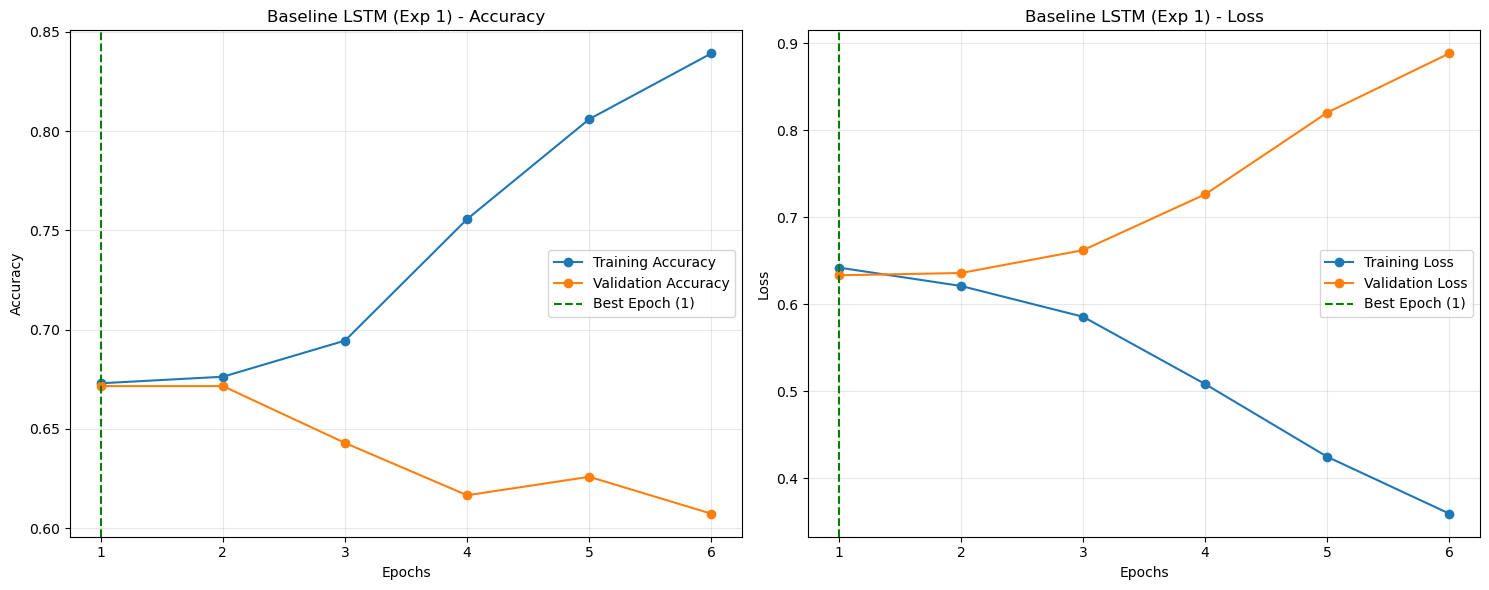

In [9]:
# --- Function Definition ---
def plot_learning_curves(history, model_name, best_ep):
    """
    Plots training & validation accuracy and loss, highlighting the best epoch.
    """
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
    plt.axvline(x=best_ep, color='green', linestyle='--', label=f'Best Epoch ({best_ep})')
    plt.title(f'{model_name} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
    plt.axvline(x=best_ep, color='green', linestyle='--', label=f'Best Epoch ({best_ep})')
    plt.title(f'{model_name} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# --- Evaluation Logic ---

# Extract Early Stopping Details for Experiment 1
best_epoch_idx = early_stopping.best_epoch
best_epoch_num = best_epoch_idx + 1
stopped_epoch_idx = early_stopping.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 1) ---")
if stopped_epoch_idx > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num}!")

# Extract exact metrics from the best epoch in Experiment 1
best_train_loss = history_lstm.history['loss'][best_epoch_idx]
best_train_acc = history_lstm.history['accuracy'][best_epoch_idx]
best_val_loss = history_lstm.history['val_loss'][best_epoch_idx]
best_val_acc = history_lstm.history['val_accuracy'][best_epoch_idx]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss:.4f} | Training Accuracy:   {best_train_acc:.4f}")
print(f"Validation Loss: {best_val_loss:.4f} | Validation Accuracy: {best_val_acc:.4f}")
print("="*40 + "\n")

# Final Model Evaluation numerically (Exp 1)
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc:.4f}")

# Evaluate the validation set to verify restored weights
val_loss_1_lstm, val_acc_1_lstm = lstm_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_1_lstm:.4f}\n")

# Execute the plotting function for the Baseline LSTM
plot_learning_curves(history_lstm, "Baseline LSTM (Exp 1)", best_epoch_num)

#### 4.2 Stacked LSTM (Exp 2)

##### 4.2.1 Architecture

In [10]:
# Initialize the model
lstm_stacked_model = Sequential()

# Define input shape
lstm_stacked_model.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
lstm_stacked_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# First LSTM Layer: return_sequences=True is required to stack another LSTM
lstm_stacked_model.add(LSTM(
    units=64, 
    return_sequences=True, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Second LSTM Layer: many-to-one summarization
lstm_stacked_model.add(LSTM(
    units=32, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Final regularization
lstm_stacked_model.add(Dropout(0.5))

# Output layer for binary classification
lstm_stacked_model.add(Dense(units=1, activation='sigmoid'))

# Compile with global learning rate
lstm_stacked_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Stacked LSTM Architecture (Experiment 2) ---")
lstm_stacked_model.summary()

--- Stacked LSTM Architecture (Experiment 2) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 3000, 64)       │        67,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,080,289 (7.94 MB)

 Trainable params: 2,080,289 (7.94 MB)

 Non-trainable params: 0 (0.00 B)

##### 4.2.2 Training

In [11]:
# Configure Early Stopping to restore weights from the best epoch
early_stopping_2 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Stacked LSTM training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_lstm_2 = lstm_stacked_model.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_2], 
    verbose=1
)

Starting Stacked LSTM training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1000s 6s/step - accuracy: 0.6757 - loss: 0.6425 - val_accuracy: 0.6716 - val_loss: 0.6325
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1063s 7s/step - accuracy: 0.6763 - loss: 0.6272 - val_accuracy: 0.6716 - val_loss: 0.6371
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 40239s 250s/step - accuracy: 0.7084 - loss: 0.5861 - val_accuracy: 0.6445 - val_loss: 0.6838
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 980s 6s/step - accuracy: 0.7704 - loss: 0.4915 - val_accuracy: 0.6313 - val_loss: 0.8172
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1000s 6s/step - accuracy: 0.8218 - loss: 0.4085 - val_accuracy: 0.6313 - val_loss: 0.9471
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1164s 7s/step - accuracy: 0.8601 - loss: 0.3317 - val_accuracy: 0.6181 - val_loss: 1.0887


##### 4.2.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 2) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6425 | Training Accuracy:   0.6757
Validation Loss: 0.6325 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6757
Final Evaluated Validation Accuracy: 0.6716



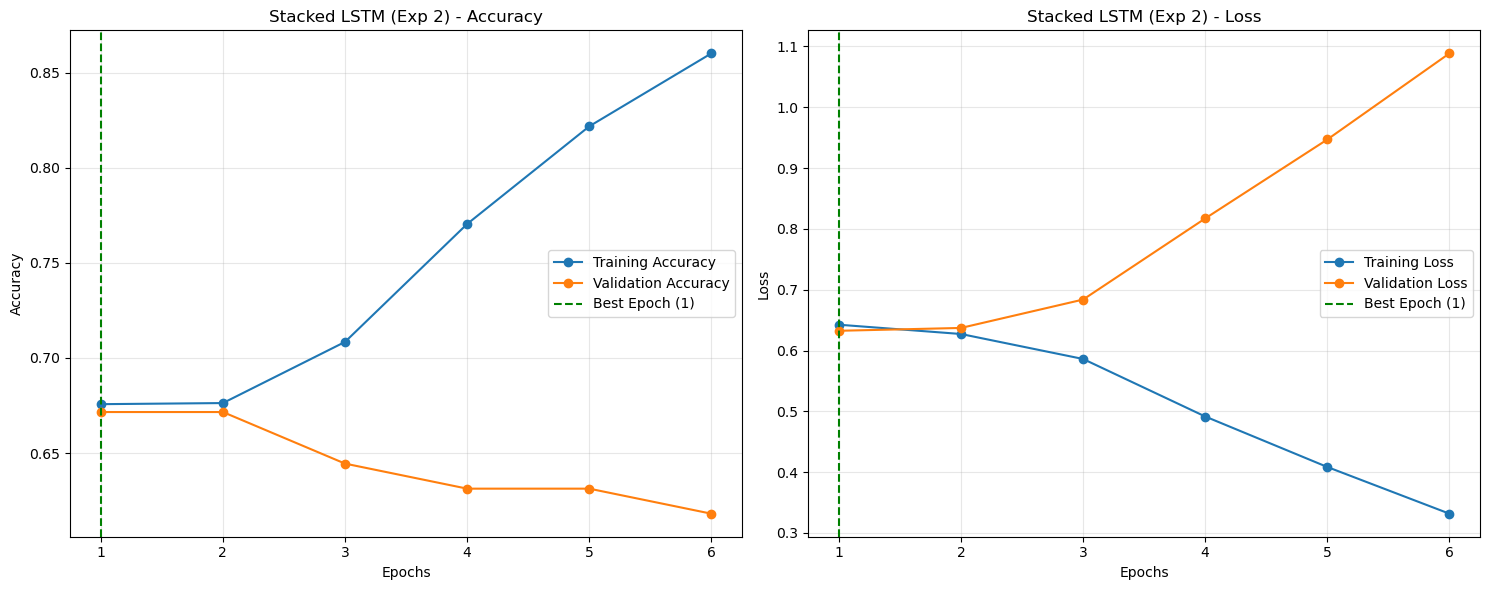

In [12]:
# Extract Early Stopping Details for Experiment 2
best_epoch_idx_2 = early_stopping_2.best_epoch
best_epoch_num_2 = best_epoch_idx_2 + 1
stopped_epoch_idx_2 = early_stopping_2.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 2) ---")
if stopped_epoch_idx_2 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_2 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_2}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_2}!")

# Extract exact metrics from the best epoch in Experiment 2
best_train_loss_2 = history_lstm_2.history['loss'][best_epoch_idx_2]
best_train_acc_2 = history_lstm_2.history['accuracy'][best_epoch_idx_2]
best_val_loss_2 = history_lstm_2.history['val_loss'][best_epoch_idx_2]
best_val_acc_2 = history_lstm_2.history['val_accuracy'][best_epoch_idx_2]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_2:.4f} | Training Accuracy:   {best_train_acc_2:.4f}")
print(f"Validation Loss: {best_val_loss_2:.4f} | Validation Accuracy: {best_val_acc_2:.4f}")
print("="*40 + "\n")

# Final Model Evaluation numerically (Exp 2)
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_2:.4f}")

# Evaluate the validation set to verify restored weights
val_loss_2_lstm, val_acc_2_lstm = lstm_stacked_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_2_lstm:.4f}\n")

# Execute the plotting function for the Stacked LSTM
plot_learning_curves(history_lstm_2, "Stacked LSTM (Exp 2)", best_epoch_num_2)

#### 4.3 Wider LSTM (Exp 3)

##### 4.3.1 Architecture

In [13]:
# Initialize the model
lstm_wider_model = Sequential()

# Define input shape
lstm_wider_model.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
lstm_wider_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Wider LSTM Layer: Increased units to 128 for higher capacity
lstm_wider_model.add(LSTM(
    units=128, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Final regularization to manage the increased parameter count
lstm_wider_model.add(Dropout(0.5))

# Output layer for binary classification
lstm_wider_model.add(Dense(units=1, activation='sigmoid'))

# Compile with global learning rate
lstm_wider_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Wider LSTM Architecture (Experiment 3) ---")
lstm_wider_model.summary()

--- Wider LSTM Architecture (Experiment 3) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128)            │       168,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,168,577 (8.27 MB)

 Trainable params: 2,168,577 (8.27 MB)

 Non-trainable params: 0 (0.00 B)

##### 4.3.2 Training

In [14]:
# Configure Early Stopping for Experiment 3
early_stopping_3 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Wider LSTM training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_lstm_3 = lstm_wider_model.fit(
    train_padded,
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_3], 
    verbose=1
)

Starting Wider LSTM training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1083s 7s/step - accuracy: 0.6736 - loss: 0.6385 - val_accuracy: 0.6716 - val_loss: 0.6340
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1132s 7s/step - accuracy: 0.6763 - loss: 0.6217 - val_accuracy: 0.6708 - val_loss: 0.6365
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1160s 7s/step - accuracy: 0.7048 - loss: 0.5726 - val_accuracy: 0.6538 - val_loss: 0.6869
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1159s 7s/step - accuracy: 0.7741 - loss: 0.4768 - val_accuracy: 0.6228 - val_loss: 0.7546
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1155s 7s/step - accuracy: 0.8235 - loss: 0.3902 - val_accuracy: 0.5910 - val_loss: 0.8232
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1155s 7s/step - accuracy: 0.8632 - loss: 0.3123 - val_accuracy: 0.5585 - val_loss: 1.0228


##### 4.3.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 3) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6385 | Training Accuracy:   0.6736
Validation Loss: 0.6340 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6736
Final Evaluated Validation Accuracy: 0.6716



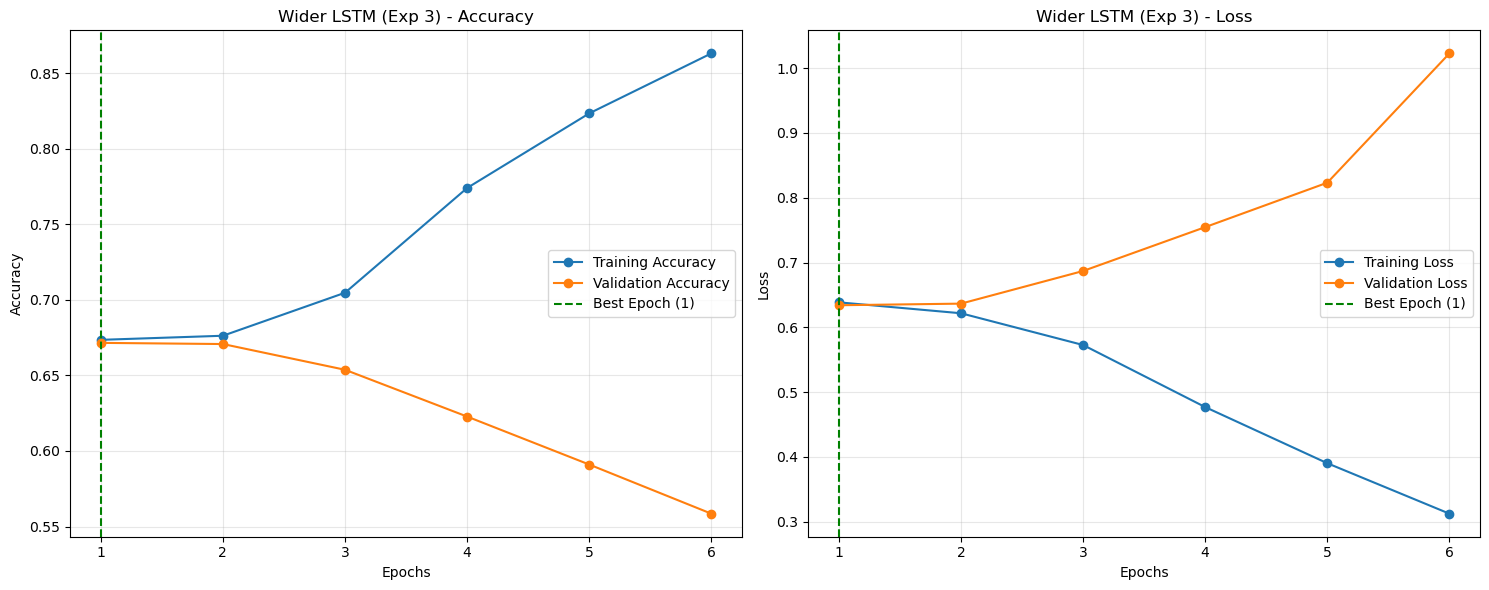

In [15]:
# Extract Early Stopping Details for Experiment 3
best_epoch_idx_3 = early_stopping_3.best_epoch
best_epoch_num_3 = best_epoch_idx_3 + 1
stopped_epoch_idx_3 = early_stopping_3.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 3) ---")
if stopped_epoch_idx_3 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_3 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_3}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_3}!")

# Extract exact metrics from the best epoch in Experiment 3
best_train_loss_3 = history_lstm_3.history['loss'][best_epoch_idx_3]
best_train_acc_3 = history_lstm_3.history['accuracy'][best_epoch_idx_3]
best_val_loss_3 = history_lstm_3.history['val_loss'][best_epoch_idx_3]
best_val_acc_3 = history_lstm_3.history['val_accuracy'][best_epoch_idx_3]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_3:.4f} | Training Accuracy:   {best_train_acc_3:.4f}")
print(f"Validation Loss: {best_val_loss_3:.4f} | Validation Accuracy: {best_val_acc_3:.4f}")
print("="*40 + "\n")

# Final Model Evaluation numerically (Exp 3)
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_3:.4f}")

# Evaluate the validation set to verify restored weights
val_loss_3_lstm, val_acc_3_lstm = lstm_wider_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_3_lstm:.4f}\n")

# Execute the plotting function for the Wider LSTM
plot_learning_curves(history_lstm_3, "Wider LSTM (Exp 3)", best_epoch_num_3)

#### 4.4 Bidirectional LSTM (Exp 4)

##### 4.4.1 Architecture

In [16]:
# Initialize the model
lstm_bidirectional_model = Sequential()

# Define input shape
lstm_bidirectional_model.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
lstm_bidirectional_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Bidirectional LSTM Layer
lstm_bidirectional_model.add(Bidirectional(LSTM(
    units=64, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
)))

# Final regularization
lstm_bidirectional_model.add(Dropout(0.5))

# Output layer for binary classification
lstm_bidirectional_model.add(Dense(units=1, activation='sigmoid'))

# Compile with global learning rate
lstm_bidirectional_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Bidirectional LSTM Architecture (Experiment 4) ---")
lstm_bidirectional_model.summary()

--- Bidirectional LSTM Architecture (Experiment 4) ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       135,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,135,809 (8.15 MB)

 Trainable params: 2,135,809 (8.15 MB)

 Non-trainable params: 0 (0.00 B)

##### 4.4.2 Training

In [17]:
# Configure Early Stopping
early_stopping_4 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Bidirectional LSTM training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_lstm_4 = lstm_bidirectional_model.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_4], 
    verbose=1
)

Starting Bidirectional LSTM training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5095s 31s/step - accuracy: 0.6734 - loss: 0.6388 - val_accuracy: 0.6716 - val_loss: 0.6342
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5190s 32s/step - accuracy: 0.6763 - loss: 0.6214 - val_accuracy: 0.6716 - val_loss: 0.6351
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5157s 32s/step - accuracy: 0.6916 - loss: 0.5862 - val_accuracy: 0.6654 - val_loss: 0.6666
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5352s 33s/step - accuracy: 0.7573 - loss: 0.4968 - val_accuracy: 0.6266 - val_loss: 0.7457
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5333s 33s/step - accuracy: 0.8202 - loss: 0.3938 - val_accuracy: 0.5995 - val_loss: 0.8135
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 5047s 31s/step - accuracy: 0.8603 - loss: 0.3199 - val_accuracy: 0.5701 - val_loss: 0.9555


##### 4.4.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 4 LSTM) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6388 | Training Accuracy:   0.6734
Validation Loss: 0.6342 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6734
Final Evaluated Validation Accuracy: 0.6716



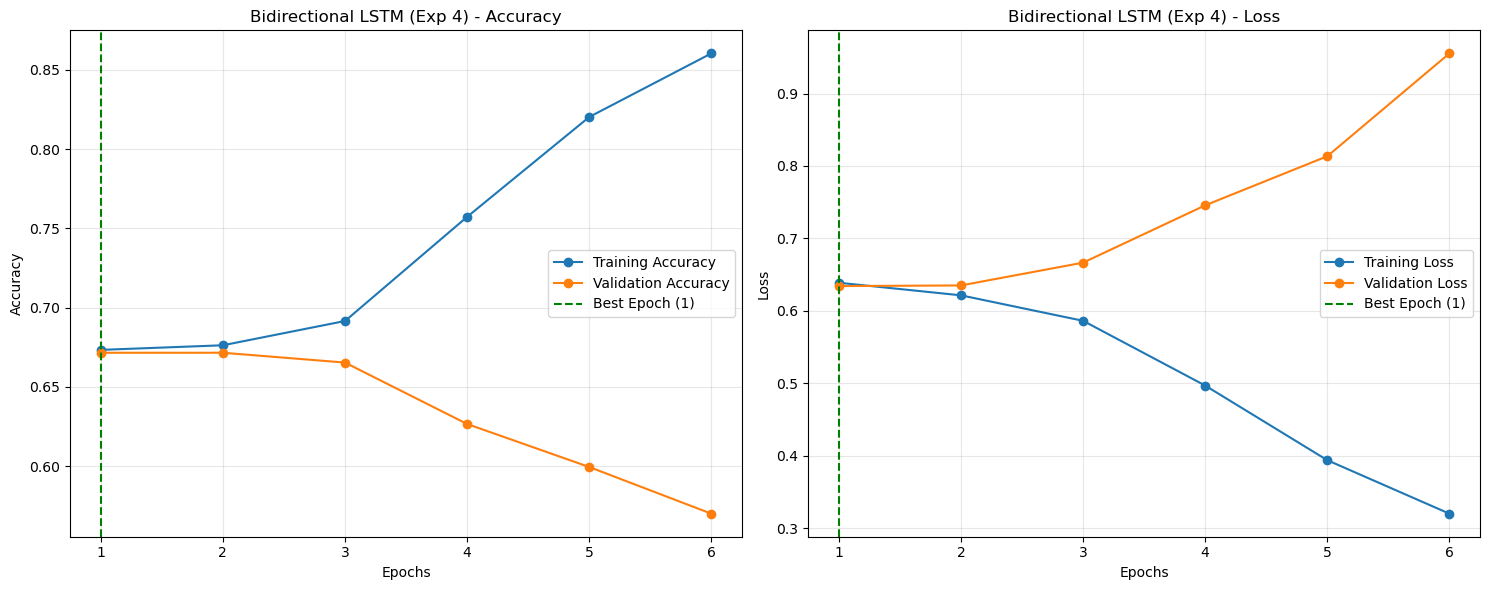

In [18]:
# Extract Early Stopping Details
best_epoch_idx_4 = early_stopping_4.best_epoch
best_epoch_num_4 = best_epoch_idx_4 + 1
stopped_epoch_idx_4 = early_stopping_4.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 4 LSTM) ---")
if stopped_epoch_idx_4 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_4 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_4}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_4}!")

# Extract exact metrics from the best epoch
best_train_loss_4 = history_lstm_4.history['loss'][best_epoch_idx_4]
best_train_acc_4 = history_lstm_4.history['accuracy'][best_epoch_idx_4]
best_val_loss_4 = history_lstm_4.history['val_loss'][best_epoch_idx_4]
best_val_acc_4 = history_lstm_4.history['val_accuracy'][best_epoch_idx_4]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_4:.4f} | Training Accuracy:   {best_train_acc_4:.4f}")
print(f"Validation Loss: {best_val_loss_4:.4f} | Validation Accuracy: {best_val_acc_4:.4f}")
print("="*40 + "\n")

# Final Model Evaluation numerically
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_4:.4f}")

# Evaluate the validation set to verify restored weights
val_loss_4_lstm, val_acc_4_lstm = lstm_bidirectional_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_4_lstm:.4f}\n")

# Execute the plotting function
plot_learning_curves(history_lstm_4, "Bidirectional LSTM (Exp 4)", best_epoch_num_4)

### 5. GRU

#### 5.1 Baseline GRU (Exp 1)

##### 5.1.1 Architecture

In [19]:
# Initialize the model
gru_model_1 = Sequential()

# Define input shape
gru_model_1.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
gru_model_1.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# GRU layer: many-to-one sequence processing
gru_model_1.add(GRU(
    units=64, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Final regularization
gru_model_1.add(Dropout(0.5))

# Output layer for binary classification
gru_model_1.add(Dense(units=1, activation='sigmoid'))

# Compile the model
gru_model_1.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Baseline GRU Architecture (Experiment 1) ---")
gru_model_1.summary()

--- Baseline GRU Architecture (Experiment 1) ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │        51,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,051,137 (7.82 MB)

 Trainable params: 2,051,137 (7.82 MB)

 Non-trainable params: 0 (0.00 B)

##### 5.1.2 Training

In [20]:
# Configure Early Stopping
early_stopping_gru_1 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Baseline GRU training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_gru_1 = gru_model_1.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_gru_1], 
    verbose=1
)

Starting Baseline GRU training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 598s 4s/step - accuracy: 0.6705 - loss: 0.6412 - val_accuracy: 0.6716 - val_loss: 0.6335
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 600s 4s/step - accuracy: 0.6763 - loss: 0.6194 - val_accuracy: 0.6716 - val_loss: 0.6374
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 620s 4s/step - accuracy: 0.6922 - loss: 0.5794 - val_accuracy: 0.6297 - val_loss: 0.6779
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 625s 4s/step - accuracy: 0.7485 - loss: 0.5118 - val_accuracy: 0.5926 - val_loss: 0.7463
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 619s 4s/step - accuracy: 0.7902 - loss: 0.4382 - val_accuracy: 0.6034 - val_loss: 0.8572
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.8289 - loss: 0.3706 - val_accuracy: 0.5809 - val_loss: 1.0035


##### 5.1.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 1) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6412 | Training Accuracy:   0.6705
Validation Loss: 0.6335 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6705
Final Evaluated Validation Accuracy: 0.6716



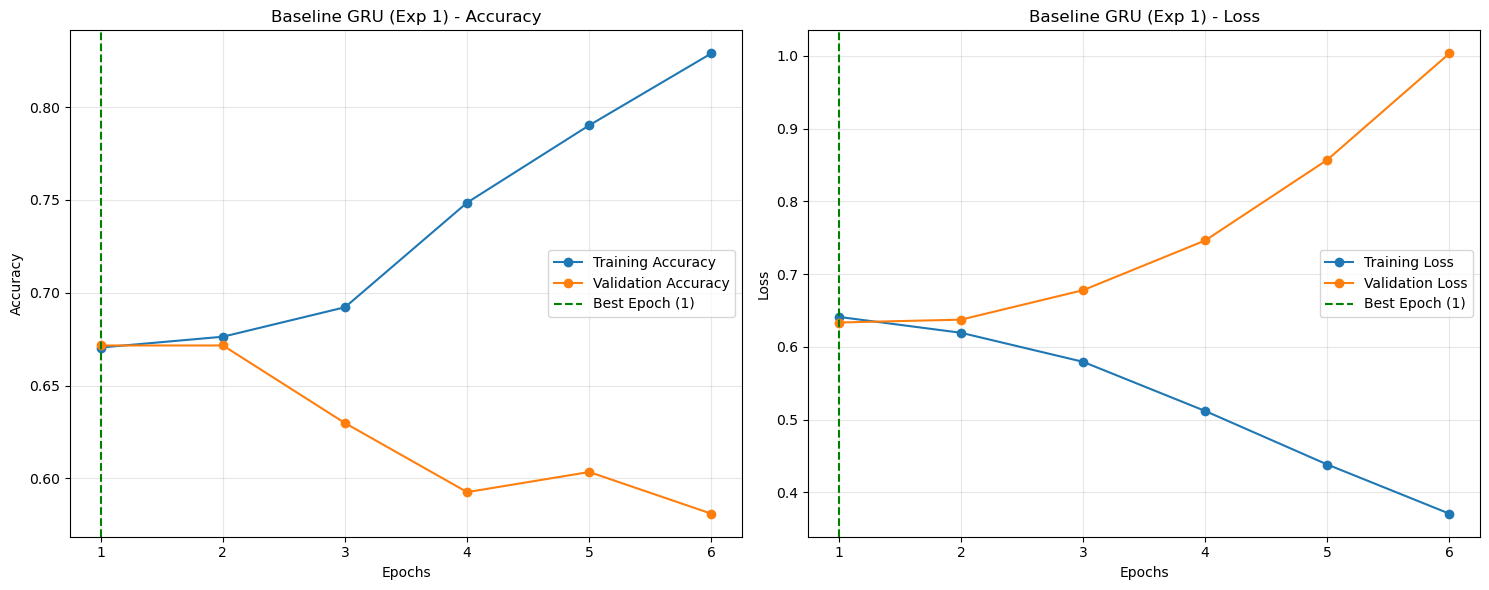

In [21]:
# Extract Early Stopping Details
best_epoch_idx_1 = early_stopping_gru_1.best_epoch
best_epoch_num_1 = best_epoch_idx_1 + 1
stopped_epoch_idx_1 = early_stopping_gru_1.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 1) ---")
if stopped_epoch_idx_1 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_1 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_1}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_1}!")

# Extract exact metrics from best epoch
best_train_loss_1 = history_gru_1.history['loss'][best_epoch_idx_1]
best_train_acc_1 = history_gru_1.history['accuracy'][best_epoch_idx_1]
best_val_loss_1 = history_gru_1.history['val_loss'][best_epoch_idx_1]
best_val_acc_1 = history_gru_1.history['val_accuracy'][best_epoch_idx_1]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_1:.4f} | Training Accuracy:   {best_train_acc_1:.4f}")
print(f"Validation Loss: {best_val_loss_1:.4f} | Validation Accuracy: {best_val_acc_1:.4f}")
print("="*40 + "\n")

# Evaluate Model numerically
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_1:.4f}")
val_loss_1_gru, val_acc_1_gru = gru_model_1.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_1_gru:.4f}\n")

# Plotting the Learning Curves
plot_learning_curves(history_gru_1, "Baseline GRU (Exp 1)", best_epoch_num_1)

#### 5.2 Stacked GRU (Exp 2)

##### 5.2.1 Architecture

In [22]:
# Initialize the model
gru_model_2 = Sequential()

# Define input shape
gru_model_2.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
gru_model_2.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# First GRU Layer: returns sequences to feed the next layer
gru_model_2.add(GRU(
    units=64, 
    return_sequences=True, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Second GRU Layer: many-to-one processing
gru_model_2.add(GRU(
    units=32, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Final regularization
gru_model_2.add(Dropout(0.5))

# Output layer
gru_model_2.add(Dense(units=1, activation='sigmoid'))

# Compile
gru_model_2.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Stacked GRU Architecture (Experiment 2) ---")
gru_model_2.summary()

--- Stacked GRU Architecture (Experiment 2) ---


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 3000, 64)       │        51,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,060,513 (7.86 MB)

 Trainable params: 2,060,513 (7.86 MB)

 Non-trainable params: 0 (0.00 B)

##### 5.2.2 Training

In [23]:
early_stopping_gru_2 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Stacked GRU training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_gru_2 = gru_model_2.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_gru_2], 
    verbose=1
)

Starting Stacked GRU training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 888s 5s/step - accuracy: 0.6740 - loss: 0.6417 - val_accuracy: 0.6716 - val_loss: 0.6329
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 872s 5s/step - accuracy: 0.6765 - loss: 0.6194 - val_accuracy: 0.6692 - val_loss: 0.6390
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 886s 5s/step - accuracy: 0.6960 - loss: 0.5827 - val_accuracy: 0.6305 - val_loss: 0.6882
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 895s 6s/step - accuracy: 0.7567 - loss: 0.4996 - val_accuracy: 0.5972 - val_loss: 0.7755
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 901s 6s/step - accuracy: 0.8111 - loss: 0.4099 - val_accuracy: 0.5786 - val_loss: 0.8848
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 903s 6s/step - accuracy: 0.8421 - loss: 0.3375 - val_accuracy: 0.5988 - val_loss: 1.0822


##### 5.2.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 2) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6417 | Training Accuracy:   0.6740
Validation Loss: 0.6329 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6740
Final Evaluated Validation Accuracy: 0.6716



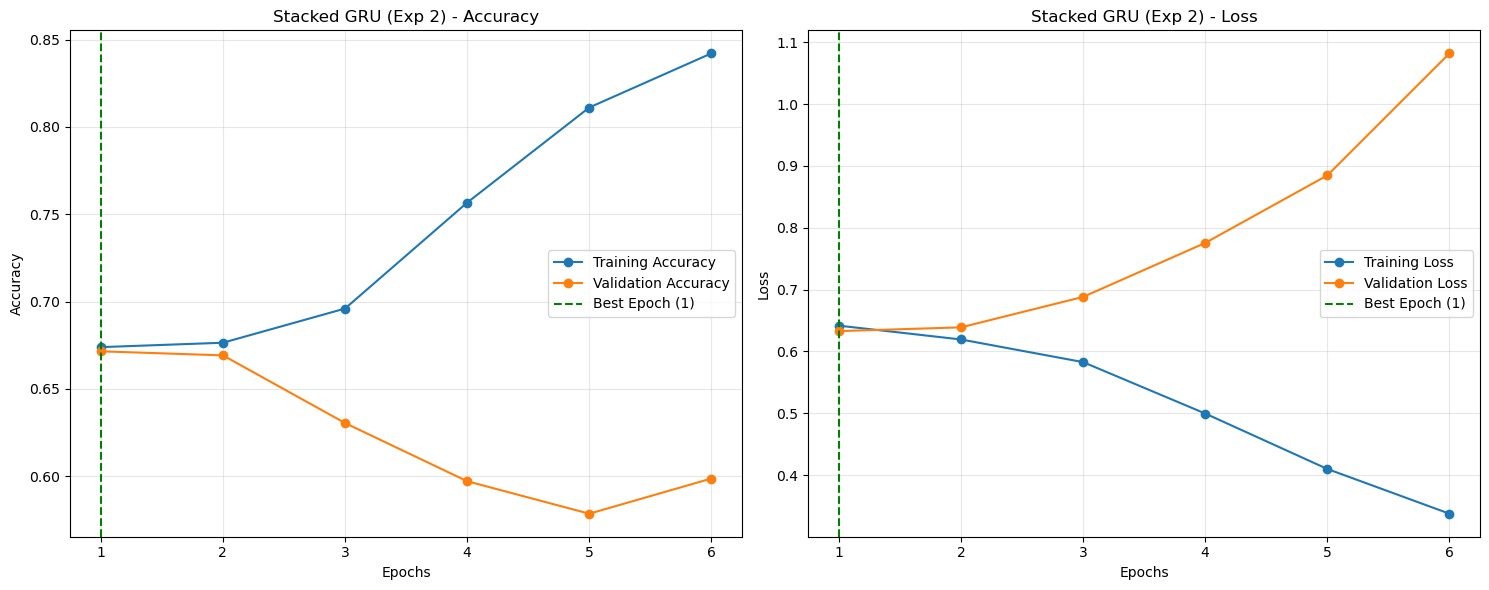

In [24]:
# Extract Early Stopping Details
best_epoch_idx_2 = early_stopping_gru_2.best_epoch
best_epoch_num_2 = best_epoch_idx_2 + 1
stopped_epoch_idx_2 = early_stopping_gru_2.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 2) ---")
if stopped_epoch_idx_2 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_2 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_2}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_2}!")

# Extract exact metrics from best epoch
best_train_loss_2 = history_gru_2.history['loss'][best_epoch_idx_2]
best_train_acc_2 = history_gru_2.history['accuracy'][best_epoch_idx_2]
best_val_loss_2 = history_gru_2.history['val_loss'][best_epoch_idx_2]
best_val_acc_2 = history_gru_2.history['val_accuracy'][best_epoch_idx_2]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_2:.4f} | Training Accuracy:   {best_train_acc_2:.4f}")
print(f"Validation Loss: {best_val_loss_2:.4f} | Validation Accuracy: {best_val_acc_2:.4f}")
print("="*40 + "\n")

# Evaluate Model numerically
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_2:.4f}")
val_loss_2_gru, val_acc_2_gru = gru_model_2.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_2_gru:.4f}\n")

# Plotting the Learning Curves
plot_learning_curves(history_gru_2, "Stacked GRU (Exp 2)", best_epoch_num_2)

#### 5.3 Wider GRU (Exp 3)

##### 5.3.1 Architecture

In [25]:
# Initialize the model
gru_model_3 = Sequential()

# Define input shape
gru_model_3.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
gru_model_3.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Wider GRU Layer: Increased units for higher capacity
gru_model_3.add(GRU(
    units=128, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
))

# Output Dropout
gru_model_3.add(Dropout(0.5))

# Output layer
gru_model_3.add(Dense(units=1, activation='sigmoid'))

# Compile
gru_model_3.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Wider GRU Architecture (Experiment 3) ---")
gru_model_3.summary()

--- Wider GRU Architecture (Experiment 3) ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 128)            │       126,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,126,849 (8.11 MB)

 Trainable params: 2,126,849 (8.11 MB)

 Non-trainable params: 0 (0.00 B)

##### 5.3.2 Training

In [26]:
early_stopping_gru_3 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Wider GRU training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_gru_3 = gru_model_3.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_gru_3], 
    verbose=1
)

Starting Wider GRU training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1004s 6s/step - accuracy: 0.6732 - loss: 0.6399 - val_accuracy: 0.6716 - val_loss: 0.6342
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 998s 6s/step - accuracy: 0.6761 - loss: 0.6152 - val_accuracy: 0.6692 - val_loss: 0.6441
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 999s 6s/step - accuracy: 0.7046 - loss: 0.5683 - val_accuracy: 0.6359 - val_loss: 0.7264
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1003s 6s/step - accuracy: 0.7637 - loss: 0.4925 - val_accuracy: 0.6065 - val_loss: 0.8036
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 994s 6s/step - accuracy: 0.8051 - loss: 0.4105 - val_accuracy: 0.6073 - val_loss: 0.8973
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 1007s 6s/step - accuracy: 0.8423 - loss: 0.3428 - val_accuracy: 0.5585 - val_loss: 1.0328


##### 5.3.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 3) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6399 | Training Accuracy:   0.6732
Validation Loss: 0.6342 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6732
Final Evaluated Validation Accuracy: 0.6716



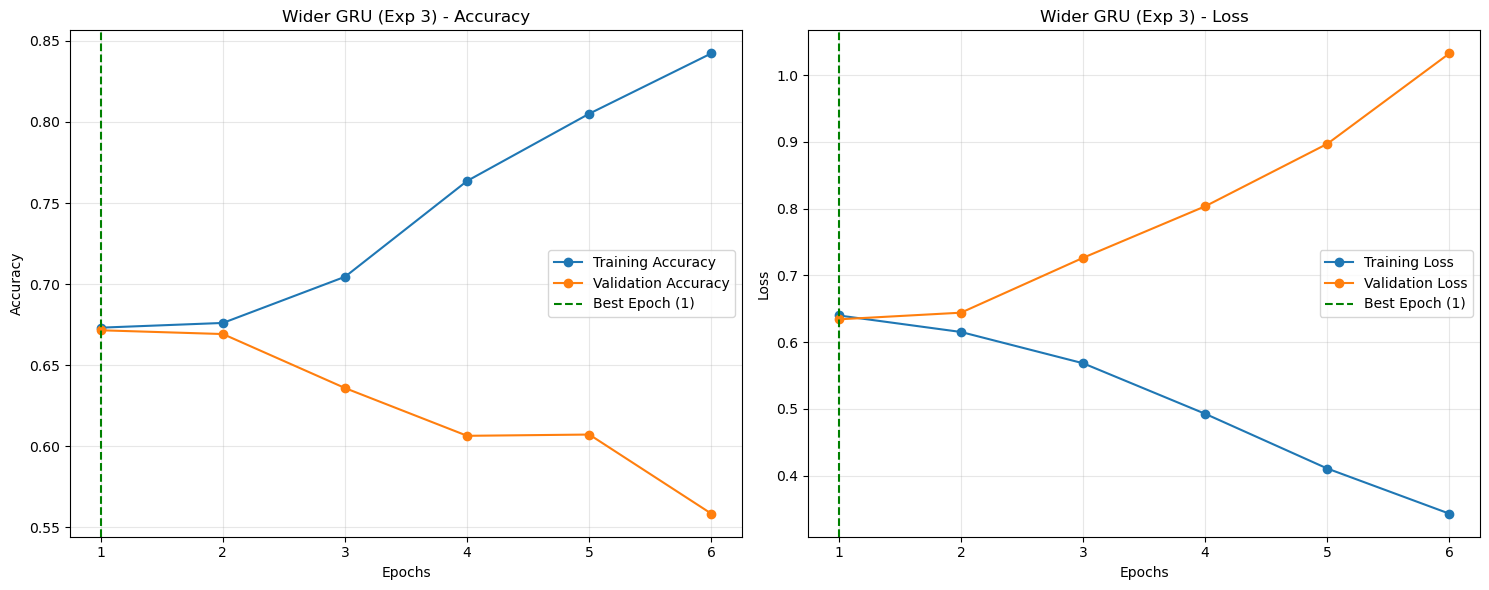

In [27]:
# Extract Early Stopping Details
best_epoch_idx_3 = early_stopping_gru_3.best_epoch
best_epoch_num_3 = best_epoch_idx_3 + 1
stopped_epoch_idx_3 = early_stopping_gru_3.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 3) ---")
if stopped_epoch_idx_3 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_3 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_3}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_3}!")

# Extract exact metrics from best epoch
best_train_loss_3 = history_gru_3.history['loss'][best_epoch_idx_3]
best_train_acc_3 = history_gru_3.history['accuracy'][best_epoch_idx_3]
best_val_loss_3 = history_gru_3.history['val_loss'][best_epoch_idx_3]
best_val_acc_3 = history_gru_3.history['val_accuracy'][best_epoch_idx_3]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_3:.4f} | Training Accuracy:   {best_train_acc_3:.4f}")
print(f"Validation Loss: {best_val_loss_3:.4f} | Validation Accuracy: {best_val_acc_3:.4f}")
print("="*40 + "\n")

# Evaluate Model numerically
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_3:.4f}")
val_loss_3_gru, val_acc_3_gru = gru_model_3.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_3_gru:.4f}\n")

# Plotting the Learning Curves
plot_learning_curves(history_gru_3, "Wider GRU (Exp 3)", best_epoch_num_3)

#### 5.4 Bidirectional GRU (Exp 4)

##### 5.4.1 Architecture

In [28]:
# Initialize the model
gru_model_4 = Sequential()

# Define input shape
gru_model_4.add(Input(shape=(max_length,)))

# Word embeddings - learning from scratch
gru_model_4.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Bidirectional GRU Layer
gru_model_4.add(Bidirectional(GRU(
    units=64, 
    return_sequences=False, 
    dropout=0.2,           
    recurrent_dropout=0.2  
)))

# Final regularization
gru_model_4.add(Dropout(0.5))

# Output layer for binary classification
gru_model_4.add(Dense(units=1, activation='sigmoid'))

# Compile the model
gru_model_4.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("--- Bidirectional GRU Architecture (Experiment 4) ---")
gru_model_4.summary()

--- Bidirectional GRU Architecture (Experiment 4) ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       102,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,102,273 (8.02 MB)

 Trainable params: 2,102,273 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

##### 5.4.2 Training

In [29]:
# Configure Early Stopping
early_stopping_gru_4 = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

print(f"Starting Bidirectional GRU training (Epochs: {epochs}, Batch Size: {batch_size})...")
history_gru_4 = gru_model_4.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_gru_4], 
    verbose=1
)

Starting Bidirectional GRU training (Epochs: 10, Batch Size: 32)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3125s 19s/step - accuracy: 0.6751 - loss: 0.6389 - val_accuracy: 0.6716 - val_loss: 0.6359
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3147s 19s/step - accuracy: 0.6763 - loss: 0.6191 - val_accuracy: 0.6716 - val_loss: 0.6387
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3123s 19s/step - accuracy: 0.6918 - loss: 0.5825 - val_accuracy: 0.6476 - val_loss: 0.6861
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3195s 20s/step - accuracy: 0.7482 - loss: 0.5098 - val_accuracy: 0.6088 - val_loss: 0.7665
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3202s 20s/step - accuracy: 0.7941 - loss: 0.4319 - val_accuracy: 0.6034 - val_loss: 0.8565
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3253s 20s/step - accuracy: 0.8334 - loss: 0.3609 - val_accuracy: 0.5786 - val_loss: 0.9826


##### 5.4.3 Evaluation


--- EARLY STOPPING SUMMARY (EXP 4 GRU) ---
Training was halted early at Epoch 6.
The best validation loss occurred at Epoch 1.
Model weights have been successfully restored to Epoch 1!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.6389 | Training Accuracy:   0.6751
Validation Loss: 0.6359 | Validation Accuracy: 0.6716

--- Final Model Evaluation (Using Restored Weights) ---
Final Training Accuracy (from history): 0.6751
Final Evaluated Validation Accuracy: 0.6716



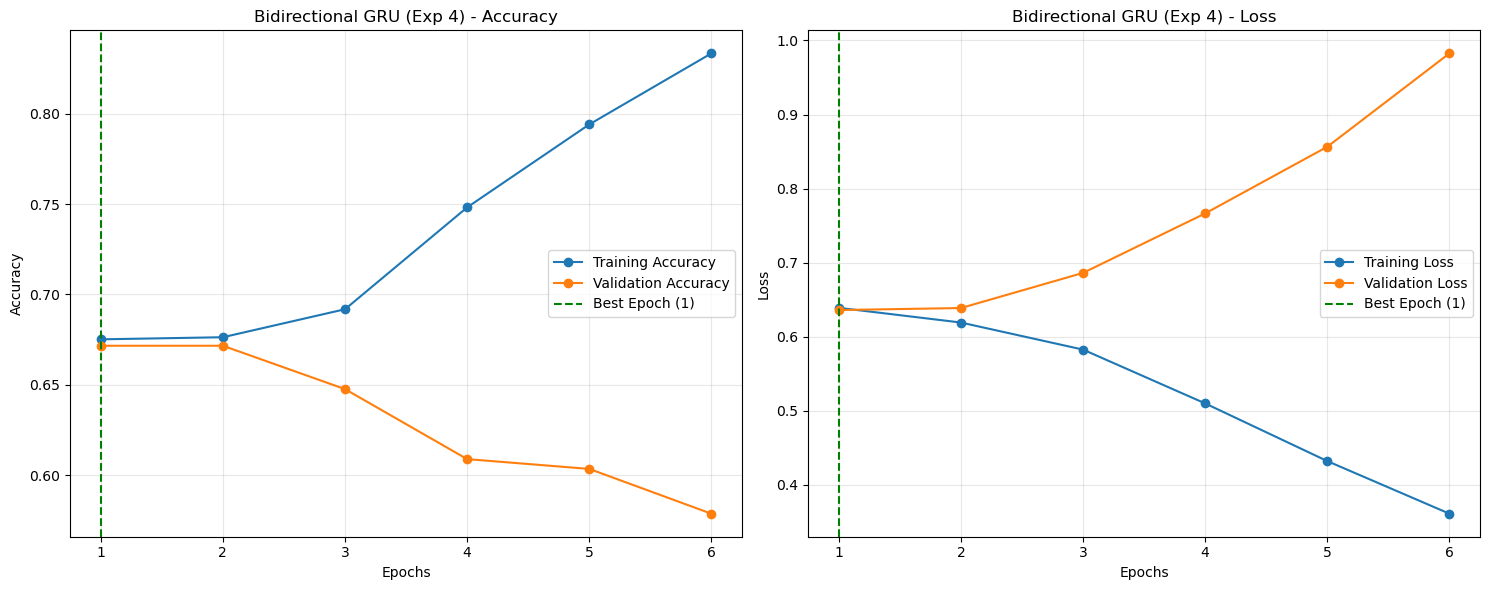

In [30]:
# Extract Early Stopping Details
best_epoch_idx_gru_4 = early_stopping_gru_4.best_epoch
best_epoch_num_gru_4 = best_epoch_idx_gru_4 + 1
stopped_epoch_idx_gru_4 = early_stopping_gru_4.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY (EXP 4 GRU) ---")
if stopped_epoch_idx_gru_4 > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_gru_4 + 1}.")
else:
    print(f"Training completed all {epochs} epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_gru_4}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_gru_4}!")

# Extract exact metrics from best epoch
best_train_loss_gru_4 = history_gru_4.history['loss'][best_epoch_idx_gru_4]
best_train_acc_gru_4 = history_gru_4.history['accuracy'][best_epoch_idx_gru_4]
best_val_loss_gru_4 = history_gru_4.history['val_loss'][best_epoch_idx_gru_4]
best_val_acc_gru_4 = history_gru_4.history['val_accuracy'][best_epoch_idx_gru_4]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_gru_4:.4f} | Training Accuracy:   {best_train_acc_gru_4:.4f}")
print(f"Validation Loss: {best_val_loss_gru_4:.4f} | Validation Accuracy: {best_val_acc_gru_4:.4f}")
print("="*40 + "\n")

# Evaluate Model numerically
print("--- Final Model Evaluation (Using Restored Weights) ---")
print(f"Final Training Accuracy (from history): {best_train_acc_gru_4:.4f}")
val_loss_4_gru, val_acc_4_gru = gru_model_4.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Accuracy: {val_acc_4_gru:.4f}\n")

# Plotting the Learning Curves
plot_learning_curves(history_gru_4, "Bidirectional GRU (Exp 4)", best_epoch_num_gru_4)

#### 5.5 Final Comparison

In [ ]:
# Collect all 8 results into a structured format
comparison_data = [
    {"Experiment": "Exp 1: Baseline LSTM",     "Accuracy": val_acc_1_lstm, "Type": "LSTM", "Units": 64,  "Stacked": False, "Bidirectional": False},
    {"Experiment": "Exp 2: Stacked LSTM",      "Accuracy": val_acc_2_lstm, "Type": "LSTM", "Units": 64,  "Stacked": True,  "Bidirectional": False},
    {"Experiment": "Exp 3: Wider LSTM",        "Accuracy": val_acc_3_lstm, "Type": "LSTM", "Units": 128, "Stacked": False, "Bidirectional": False},
    {"Experiment": "Exp 4: Bidirectional LSTM","Accuracy": val_acc_4_lstm, "Type": "LSTM", "Units": 64,  "Stacked": False, "Bidirectional": True},
    
    {"Experiment": "Exp 1: Baseline GRU",      "Accuracy": val_acc_1_gru,  "Type": "GRU",  "Units": 64,  "Stacked": False, "Bidirectional": False},
    {"Experiment": "Exp 2: Stacked GRU",       "Accuracy": val_acc_2_gru,  "Type": "GRU",  "Units": 64,  "Stacked": True,  "Bidirectional": False},
    {"Experiment": "Exp 3: Wider GRU",         "Accuracy": val_acc_3_gru,  "Type": "GRU",  "Units": 128, "Stacked": False, "Bidirectional": False},
    {"Experiment": "Exp 4: Bidirectional GRU", "Accuracy": val_acc_4_gru,  "Type": "GRU",  "Units": 64,  "Stacked": False, "Bidirectional": True}
]

# Create DataFrame and find the winner
comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Print the comparison table
print("--- Final RNN Performance Comparison ---")
print(comparison_df[['Experiment', 'Accuracy']])

# Save the winning architecture parameters
winner_info = comparison_df.iloc[0]
WINNER_TYPE = winner_info['Type']
WINNER_UNITS = winner_info['Units']
IS_STACKED = winner_info['Stacked']
IS_BIDIRECTIONAL = winner_info['Bidirectional']

print("\n" + "="*50)
print(f"THE WINNER IS: {winner_info['Experiment']}")
print(f"Validation Accuracy: {winner_info['Accuracy']:.4f}")
print("="*50)

--- Final RNN Performance Comparison ---
                  Experiment  Accuracy
0       Exp 1: Baseline LSTM  0.671572
1        Exp 2: Stacked LSTM  0.671572
2          Exp 3: Wider LSTM  0.671572
3  Exp 4: Bidirectional LSTM  0.671572
4        Exp 1: Baseline GRU  0.671572
5         Exp 2: Stacked GRU  0.671572
6           Exp 3: Wider GRU  0.671572
7   Exp 4: Bidirectional GRU  0.671572

THE WINNER IS: Exp 1: Baseline LSTM
Validation Accuracy: 0.6716


### 6. Attention mechanism

#### 6.1 Attention with Winner Model

#####  6.1.1 Architecture

In [ ]:
# # Input and Embedding
# inputs = Input(shape=(max_length,))
# x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)

# # Cast units to native Python integer to prevent Keras TypeErrors
# units_int = int(WINNER_UNITS)

# # Dynamic RNN Construction based on Winner
# # Note: return_sequences=True is required for Attention to work properly
# if WINNER_TYPE == 'LSTM':
#     if IS_BIDIRECTIONAL:
#         rnn_out = Bidirectional(LSTM(units=units_int, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
#     elif IS_STACKED:
#         x = LSTM(units=64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
#         rnn_out = LSTM(units=32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
#     else:
#         rnn_out = LSTM(units=units_int, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
# else: # GRU
#     if IS_BIDIRECTIONAL:
#         rnn_out = Bidirectional(GRU(units=units_int, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(x)
#     elif IS_STACKED:
#         x = GRU(units=64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
#         rnn_out = GRU(units=32, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
#     else:
#         rnn_out = GRU(units=units_int, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)

# # Attention Layer
# # Learns which time-steps in the sequence are most important
# attention_out = Attention(name="Attention_Layer")([rnn_out, rnn_out])

# # Memory / Aggregation Layer
# # GlobalAveragePooling1D acts as a 'memory' by summarizing the attended information
# memory_vector = GlobalAveragePooling1D(name="Memory_Aggregation")(attention_out)

# # Output
# x = Dropout(0.5)(memory_vector)
# outputs = Dense(1, activation='sigmoid')(x)

# # Compile
# attention_model = Model(inputs=inputs, outputs=outputs)
# attention_model.compile(
#     optimizer=Adam(learning_rate=0.0005), 
#     loss='binary_crossentropy', 
#     metrics=['accuracy']
# )

# print(f"--- Attention-Enhanced {WINNER_TYPE} Architecture ---")
# attention_model.summary()

# since all models have the same validation accuracy of 0.6716, we picked bi-directional gru to be used for the attention mechanism. 

In [ ]:
# since all RNN models have the same validation accuracy, we decided to go with bidirectional GRU 
# (most sophisticated architecutre) for the attention mechanism.

# Input and Embedding
inputs = Input(shape=(max_length,))
x = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs)

# Explicitly forcing the Bidirectional GRU (units=64)
# Note: return_sequences=True must be set INSIDE the GRU so Attention gets the full sequence
rnn_out = Bidirectional(GRU(
    units=64, 
    return_sequences=True, 
    dropout=0.2, 
    recurrent_dropout=0.2
))(x)

# Attention Layer
# Learns which time-steps (words) in the sequence are most important
attention_out = Attention(name="Attention_Layer")([rnn_out, rnn_out])

# Memory / Aggregation Layer
# GlobalAveragePooling1D acts as a 'memory' by summarizing the attended information
memory_vector = GlobalAveragePooling1D(name="Memory_Aggregation")(attention_out)

# Output
x = Dropout(0.5)(memory_vector)
outputs = Dense(1, activation='sigmoid')(x)

# Build and Compile
attention_model = Model(inputs=inputs, outputs=outputs)
attention_model.compile(
    optimizer=Adam(learning_rate=0.0005), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

print("--- Attention-Enhanced Bidirectional GRU Architecture ---")
attention_model.summary()

--- Attention-Enhanced Bidirectional GRU Architecture ---


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 3000, 200) │  2,000,000 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 3000, 128) │    102,144 │ embedding_8[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attention_Layer     │ (None, 3000, 128) │          0 │ bidirectional_2[… │
│ (Attention)         │                   │            │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Memory_Aggregation  │ (None, 128)       │          0 │ Attention_Layer[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ Memory_Aggregati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │        129 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,102,273 (8.02 MB)

 Trainable params: 2,102,273 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

##### 6.1.2 Training 

In [34]:
early_stopping_att = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

print(f"Training Attention Model (Base: {WINNER_TYPE})...")
history_att = attention_model.fit(
    train_padded, 
    y_train, 
    epochs=epochs, 
    batch_size=batch_size,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_att], 
    verbose=1
)

Training Attention Model (Base: LSTM)...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 2826s 17s/step - accuracy: 0.6726 - loss: 0.6392 - val_accuracy: 0.6716 - val_loss: 0.6321
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3133s 19s/step - accuracy: 0.6734 - loss: 0.6360 - val_accuracy: 0.6716 - val_loss: 0.6330
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3111s 19s/step - accuracy: 0.6724 - loss: 0.6332 - val_accuracy: 0.6716 - val_loss: 0.6323
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3088s 19s/step - accuracy: 0.6738 - loss: 0.6277 - val_accuracy: 0.6716 - val_loss: 0.6269
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 2991s 18s/step - accuracy: 0.6852 - loss: 0.6070 - val_accuracy: 0.6863 - val_loss: 0.6145
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3096s 19s/step - accuracy: 0.7044 - loss: 0.5817 - val_accuracy: 0.6847 - val_loss: 0.6174
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 3000s 19s/step - accuracy: 0.7179 - loss: 0.5609 - val_accuracy: 0.6824 - val_loss: 0.6310
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 30

##### 6.1.3 Evaluation


--- ATTENTION MODEL PERFORMANCE ---
Best Epoch: 5
Final Validation Accuracy: 0.6863
Previous Winner Accuracy: 0.6716



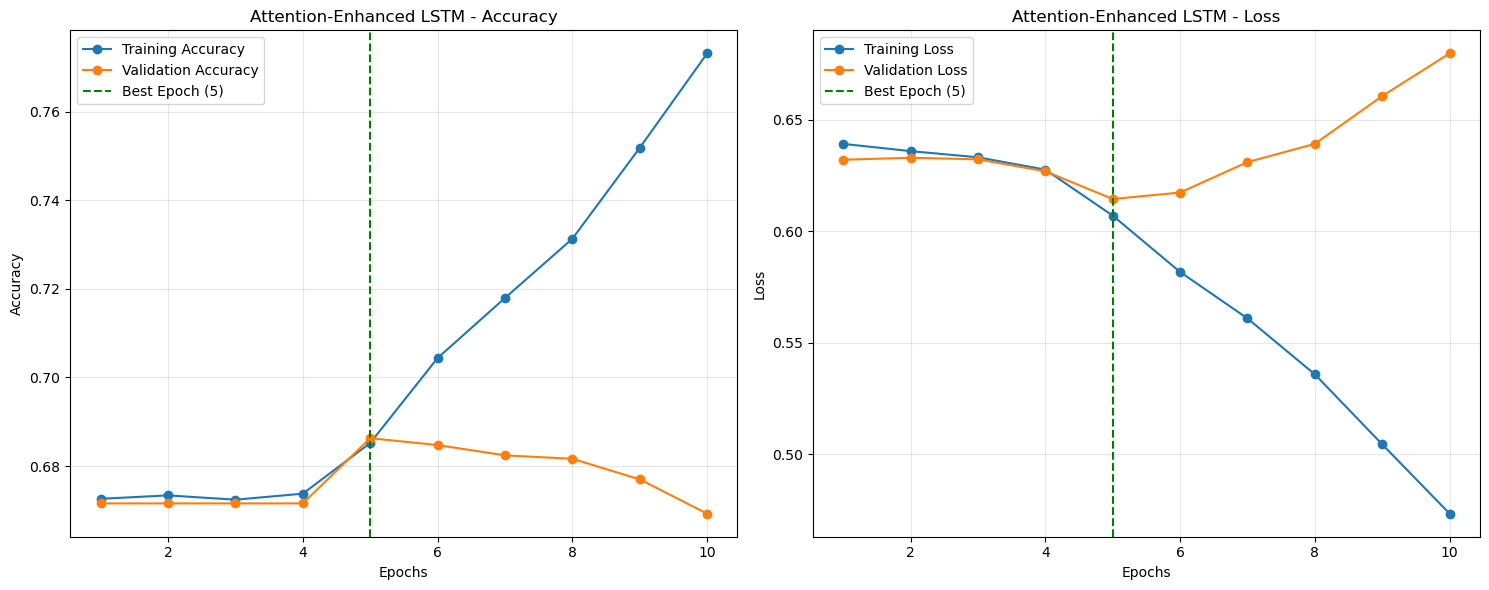

In [ ]:
# Extract Details
best_epoch_idx_att = early_stopping_att.best_epoch
best_epoch_num_att = best_epoch_idx_att + 1

# Evaluation metrics
val_loss_att, val_acc_att = attention_model.evaluate(val_padded, y_val, verbose=0)

print("\n" + "="*40)
print("--- ATTENTION MODEL PERFORMANCE ---")
print(f"Best Epoch: {best_epoch_num_att}")
print(f"Final Validation Accuracy: {val_acc_att:.4f}")
print(f"Previous Winner Accuracy: {winner_info['Accuracy']:.4f}")
print("="*40 + "\n")

# Use your existing plotting function
plot_learning_curves(history_att, f"Attention-Enhanced {WINNER_TYPE}", best_epoch_num_att)

# NOTE: in the graph title it say LSTM but it should be bidirectional GRU which corresponds to the architecture used in the previous 
# cell 6.1.1(the second cell in 6.1.1 and not the commented out code).

#### 6.2 FinBert and Bidirectional GRU (hybrid Model)

##### 6.2.1 Architecture

In [ ]:
# ==========================================
# TOKENIZATION
# ==========================================
print("Loading Tokenizer and generating encodings...")
tokenizer = BertTokenizer.from_pretrained("ProsusAI/finbert")
bert_max_length = 512 

# Convert text data to FinBERT tensor format
train_encodings = tokenizer(list(X_train), truncation=True, padding='max_length', max_length=bert_max_length, return_tensors='tf')
val_encodings = tokenizer(list(X_val), truncation=True, padding='max_length', max_length=bert_max_length, return_tensors='tf')

# ==========================================
# CUSTOM FINBERT WRAPPER (KERAS 3 SERIALIZATION FIX)
# ==========================================
@tf.keras.utils.register_keras_serializable()
class FinBERTLayer(Layer):
    def __init__(self, model, **kwargs):
        super(FinBERTLayer, self).__init__(**kwargs)
        self.model = model

    def call(self, inputs):
        input_ids, attention_mask = inputs
        outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return outputs.last_hidden_state

    # This override satisfies Keras 3's serialization requirement
    def get_config(self):
        config = super().get_config()
        return config

# ==========================================
# BUILD HYBRID MODEL
# ==========================================
print("Building Hybrid Architecture...")
finbert_base = TFAutoModel.from_pretrained("ProsusAI/finbert")
finbert_base.trainable = False 

# Define Inputs
input_ids = Input(shape=(bert_max_length,), dtype=tf.int32, name="input_ids")
attention_mask = Input(shape=(bert_max_length,), dtype=tf.int32, name="attention_mask")

# Embeddings Layer
sequence_output = FinBERTLayer(finbert_base, name="FinBERT_Embeddings")([input_ids, attention_mask])

# Bi-GRU Layer
rnn_out = Bidirectional(GRU(units=64, return_sequences=True, dropout=0.2), name="Bi-GRU_Processor")(sequence_output)

# Attention Layer
attention_out = Attention(name="Custom_Attention_Layer")([rnn_out, rnn_out])

# Pooling & Output
memory_vector = GlobalAveragePooling1D(name="Memory_Aggregation")(attention_out)
x = Dropout(0.5)(memory_vector)
outputs = Dense(1, activation='sigmoid', name="Final_Output")(x)

# Build and Compile
hybrid_model = Model(inputs=[input_ids, attention_mask], outputs=outputs)
hybrid_model.compile(optimizer=Adam(learning_rate=0.0005), loss='binary_crossentropy', metrics=['accuracy'])

hybrid_model.summary()

Loading Tokenizer and generating encodings...
Building Hybrid Architecture...



tf_model.h5:   0%|          | 0.00/438M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertModel.

All the layers of TFBertModel were initialized from the model checkpoint at ProsusAI/finbert.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions without further training.


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ FinBERT_Embeddings  │ (None, 512, 768)  │          0 │ input_ids[0][0],  │
│ (FinBERTLayer)      │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Bi-GRU_Processor    │ (None, 512, 128)  │    320,256 │ FinBERT_Embeddin… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Custom_Attention_L… │ (None, 512, 128)  │          0 │ Bi-GRU_Processor… │
│ (Attention)         │                   │            │ Bi-GRU_Processor… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Memory_Aggregation  │ (None, 128)       │          0 │ Custom_Attention… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ Memory_Aggregati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Final_Output        │ (None, 1)         │        129 │ dropout_9[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 320,385 (1.22 MB)

 Trainable params: 320,385 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

##### 6.2.2 Training

In [ ]:
# --- SAFETY CHECK: THE SMOKE TEST ---
# We run 1 batch to ensure there are no tensor/serialization errors.
print("Running Smoke Test (1 batch)...")
smoke_x = {"input_ids": train_encodings['input_ids'][:2], "attention_mask": train_encodings['attention_mask'][:2]}
smoke_y = y_train[:2]
hybrid_model.train_on_batch(smoke_x, smoke_y)
print("✅ Smoke Test Passed! Starting full training...")

# ==========================================
# DEFINE CALLBACKS
# ==========================================
callbacks_list = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    # Crucial: save_weights_only=True bypasses the NotImplementedError
    ModelCheckpoint(
        filepath='hybrid_finbert_weights.weights.h5', 
        monitor='val_loss', save_best_only=True, save_weights_only=True, verbose=1
    )
]

# ==========================================
# TRAIN THE MODEL
# ==========================================
history_hybrid = hybrid_model.fit(
    x={"input_ids": train_encodings['input_ids'], "attention_mask": train_encodings['attention_mask']},
    y=y_train, 
    epochs=10, 
    batch_size=16, 
    validation_data=({"input_ids": val_encodings['input_ids'], "attention_mask": val_encodings['attention_mask']}, y_val),
    callbacks=callbacks_list, 
    verbose=1
)

Running Smoke Test (1 batch)...
✅ Smoke Test Passed! Starting full training...
Epoch 1/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6311 - loss: 0.6872
Epoch 1: val_loss improved from None to 0.68098, saving model to hybrid_finbert_weights.weights.h5

Epoch 1: finished saving model to hybrid_finbert_weights.weights.h5
323/323 ━━━━━━━━━━━━━━━━━━━━ 2518s 8s/step - accuracy: 0.6341 - loss: 0.6787 - val_accuracy: 0.6716 - val_loss: 0.6810 - learning_rate: 5.0000e-04
Epoch 2/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6456 - loss: 0.6630
Epoch 2: val_loss improved from 0.68098 to 0.65010, saving model to hybrid_finbert_weights.weights.h5

Epoch 2: finished saving model to hybrid_finbert_weights.weights.h5
323/323 ━━━━━━━━━━━━━━━━━━━━ 2553s 8s/step - accuracy: 0.6538 - loss: 0.6568 - val_accuracy: 0.6716 - val_loss: 0.6501 - learning_rate: 5.0000e-04
Epoch 3/10
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6575 - loss: 0.6558
Epoch 3: val_loss improved from 0

##### 6.2.3 Evaluation

Evaluating final model...
41/41 ━━━━━━━━━━━━━━━━━━━━ 451s 11s/step - accuracy: 0.6716 - loss: 0.6381

Final Validation Accuracy: 0.6716


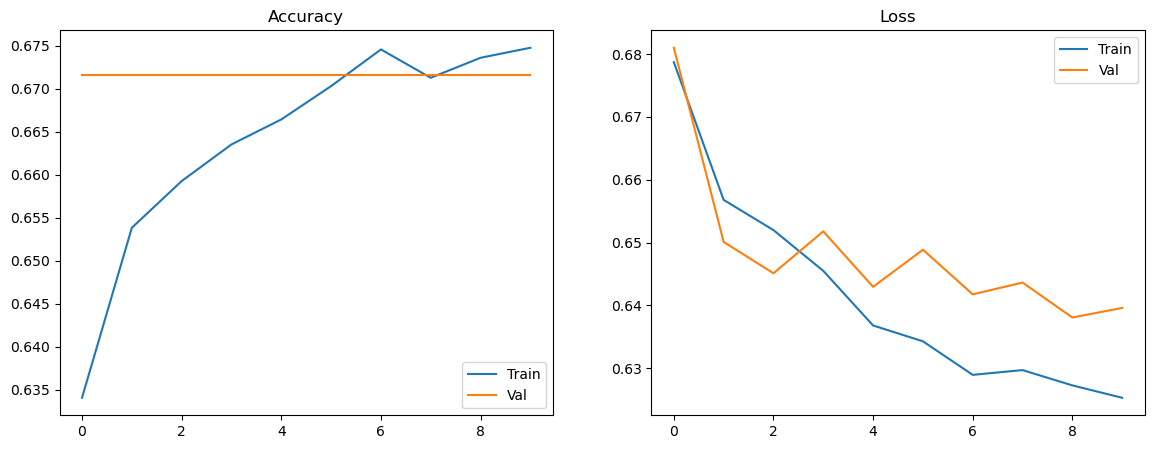

In [40]:
print("Evaluating final model...")
results = hybrid_model.evaluate(
    x={"input_ids": val_encodings['input_ids'], "attention_mask": val_encodings['attention_mask']},
    y=y_val, verbose=1
)
print(f"\nFinal Validation Accuracy: {results[1]:.4f}")

# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history_hybrid.history['accuracy'], label='Train'); ax1.plot(history_hybrid.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history_hybrid.history['loss'], label='Train'); ax2.plot(history_hybrid.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend()
plt.show()

### 7. CNN

#### 7.1 Baseline CNN

##### 7.1.1 Architecture

In [41]:
# Initialize the model
cnn_model = Sequential()

# Add an explicit Input layer
cnn_model.add(Input(shape=(max_length,)))

# Add the Embedding Layer
# Motivation: Maps integer-encoded words into dense vectors of fixed size.
cnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# Add the Conv1D Layer
cnn_model.add(Conv1D(filters=128, kernel_size=5, activation='relu'))

# Add Global Max Pooling Layer
cnn_model.add(GlobalMaxPooling1D())

# Add a Dropout Layer (Regularization)
cnn_model.add(Dropout(0.5))

# Add the Output Layer
cnn_model.add(Dense(units=1, activation='sigmoid'))

# Compile the Model
cnn_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Display the architecture
print("--- 1D CNN Model Architecture ---")
cnn_model.summary()

--- 1D CNN Model Architecture ---


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 2996, 128)      │       128,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,128,257 (8.12 MB)

 Trainable params: 2,128,257 (8.12 MB)

 Non-trainable params: 0 (0.00 B)

##### 7.1.2 Training

In [42]:
# Reset Early Stopping for the CNN model
early_stopping_cnn = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

# Train the CNN Model
print("Starting CNN training...")
history_cnn = cnn_model.fit(
    train_padded, 
    y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_cnn],
    verbose=1
)


Starting CNN training...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 42s 253ms/step - accuracy: 0.6730 - loss: 0.6374 - val_accuracy: 0.6716 - val_loss: 0.6303
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.6776 - loss: 0.6166 - val_accuracy: 0.6739 - val_loss: 0.6143
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.6986 - loss: 0.5845 - val_accuracy: 0.6902 - val_loss: 0.6029
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 253ms/step - accuracy: 0.7114 - loss: 0.5649 - val_accuracy: 0.7002 - val_loss: 0.5988
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.7466 - loss: 0.5240 - val_accuracy: 0.6995 - val_loss: 0.6059
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.7652 - loss: 0.4889 - val_accuracy: 0.6956 - val_loss: 0.6216
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - accuracy: 0.7933 - loss: 0.4520 - val_accuracy: 0.6894 - val_loss: 0.6473
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 41s 252ms/step - a

##### 7.1.3 Evaluation


--- EARLY STOPPING SUMMARY ---
Training was halted early at Epoch 9.
The best validation loss occurred at Epoch 4.
Model weights have been successfully restored to Epoch 4!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.5649 | Training Accuracy:   0.7114
Validation Loss: 0.5988 | Validation Accuracy: 0.7002

--- Final CNN Model Evaluation (Using Restored Weights) ---
Final Training Loss: 0.5649
Final Training Accuracy: 0.7114
Final Evaluated Validation Loss: 0.5988
Final Evaluated Validation Accuracy: 0.7002



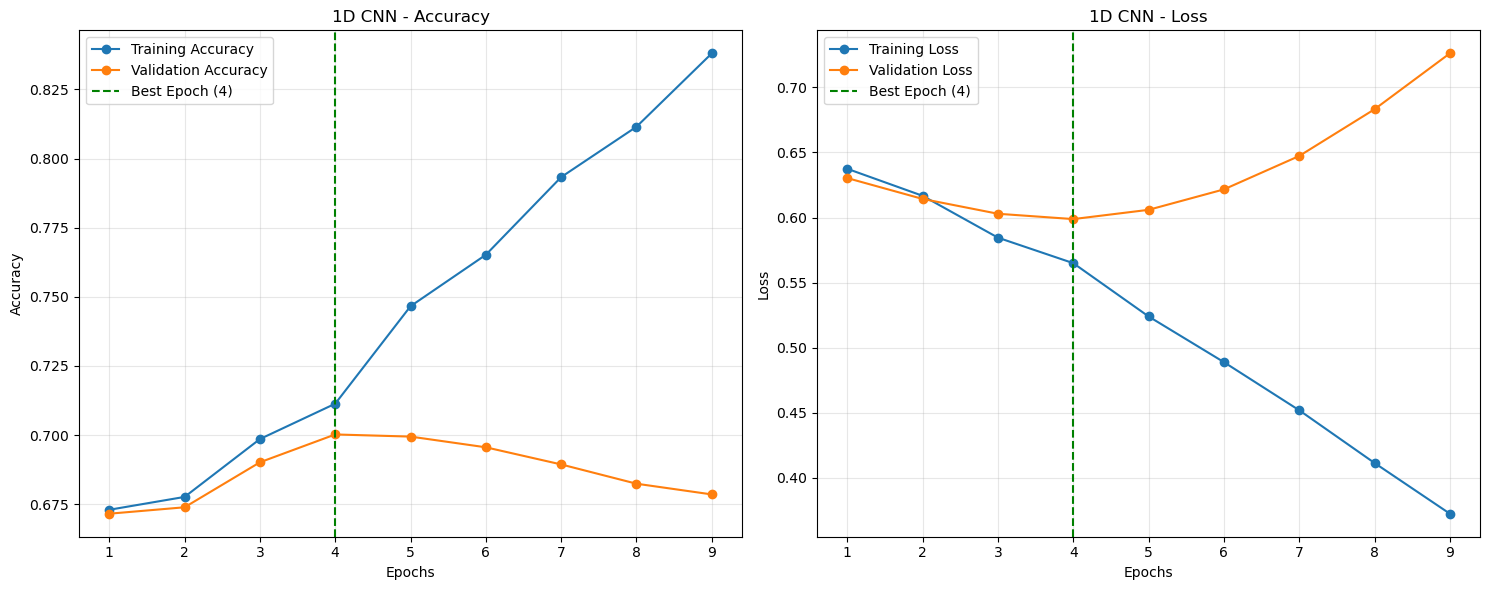

In [ ]:
# Extract Early Stopping Details
best_epoch_idx_cnn = early_stopping_cnn.best_epoch
best_epoch_num_cnn = best_epoch_idx_cnn + 1
stopped_epoch_idx_cnn = early_stopping_cnn.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY ---")
if stopped_epoch_idx_cnn > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_cnn + 1}.")
else:
    print(f"Training completed all epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_cnn}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_cnn}!")

# Extract the exact metrics recorded during that best epoch
best_train_loss_cnn = history_cnn.history['loss'][best_epoch_idx_cnn]
best_train_acc_cnn = history_cnn.history['accuracy'][best_epoch_idx_cnn]
best_val_loss_cnn = history_cnn.history['val_loss'][best_epoch_idx_cnn]
best_val_acc_cnn = history_cnn.history['val_accuracy'][best_epoch_idx_cnn]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_cnn:.4f} | Training Accuracy:   {best_train_acc_cnn:.4f}")
print(f"Validation Loss: {best_val_loss_cnn:.4f} | Validation Accuracy: {best_val_acc_cnn:.4f}")
print("="*40 + "\n")

# Evaluate the Model (This proves the weights were restored!)
print("--- Final CNN Model Evaluation (Using Restored Weights) ---")
# Print the exact history numbers instead of re-evaluating the training set
print(f"Final Training Loss: {best_train_loss_cnn:.4f}")
print(f"Final Training Accuracy: {best_train_acc_cnn:.4f}")

# Evaluate the validation set to prove the weights restored correctly
val_loss_cnn, val_acc_cnn = cnn_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Loss: {val_loss_cnn:.4f}")
print(f"Final Evaluated Validation Accuracy: {val_acc_cnn:.4f}\n")

# Plot the results 
plot_learning_curves(history_cnn, "1D CNN", best_epoch_num_cnn)

#### 7.2 Deep Sequential CNN

##### 7.2.1 Architecture

In [44]:
# Initialize the Deep Sequential CNN model
deep_cnn_model = Sequential()

# Add an explicit Input layer
deep_cnn_model.add(Input(shape=(max_length,)))

# Add the Embedding Layer
deep_cnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))

# First Conv Block (Broader context: 5 words)
deep_cnn_model.add(Conv1D(filters=64, kernel_size=5, activation='relu'))
deep_cnn_model.add(MaxPooling1D(pool_size=2))

# Second Conv Block (Finer details: 3 words)
deep_cnn_model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
deep_cnn_model.add(GlobalMaxPooling1D())

# Fully Connected block with Dropout for regularization
deep_cnn_model.add(Dense(64, activation='relu'))
deep_cnn_model.add(Dropout(0.5))

# Add the Output Layer
deep_cnn_model.add(Dense(1, activation='sigmoid'))

# Compile the Model
deep_cnn_model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Display the architecture
print("--- Deep Sequential CNN Model Architecture ---")
deep_cnn_model.summary()

--- Deep Sequential CNN Model Architecture ---


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ (None, 3000, 200)      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 2996, 64)       │        64,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1498, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1496, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,089 (8.00 MB)

 Trainable params: 2,097,089 (8.00 MB)

 Non-trainable params: 0 (0.00 B)

##### 7.2.2 Training 

In [45]:
# Reset Early Stopping for the Deep CNN
early_stopping_deep = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

# Train the Deep Sequential CNN
print("Starting Deep Sequential CNN training...")
history_deep = deep_cnn_model.fit(
    train_padded, 
    y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_deep],
    verbose=1
)


Starting Deep Sequential CNN training...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 28s 164ms/step - accuracy: 0.6734 - loss: 0.6375 - val_accuracy: 0.6716 - val_loss: 0.6330
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.6763 - loss: 0.6256 - val_accuracy: 0.6716 - val_loss: 0.6174
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 164ms/step - accuracy: 0.6811 - loss: 0.5956 - val_accuracy: 0.6878 - val_loss: 0.6106
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 164ms/step - accuracy: 0.7193 - loss: 0.5489 - val_accuracy: 0.6940 - val_loss: 0.6732
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 164ms/step - accuracy: 0.7894 - loss: 0.4433 - val_accuracy: 0.6894 - val_loss: 0.9583
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 165ms/step - accuracy: 0.8776 - loss: 0.3088 - val_accuracy: 0.6747 - val_loss: 1.0353
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27s 166ms/step - accuracy: 0.9045 - loss: 0.2485 - val_accuracy: 0.6026 - val_loss: 0.9857
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 27

##### 7.2.3 Evaluation


--- EARLY STOPPING SUMMARY ---
Training was halted early at Epoch 8.
The best validation loss occurred at Epoch 3.
Model weights have been successfully restored to Epoch 3!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.5956 | Training Accuracy:   0.6811
Validation Loss: 0.6106 | Validation Accuracy: 0.6878

--- Final Deep Sequential CNN Evaluation (Using Restored Weights) ---
Final Training Loss: 0.5956
Final Training Accuracy: 0.6811
Final Evaluated Validation Loss: 0.6106
Final Evaluated Validation Accuracy: 0.6878



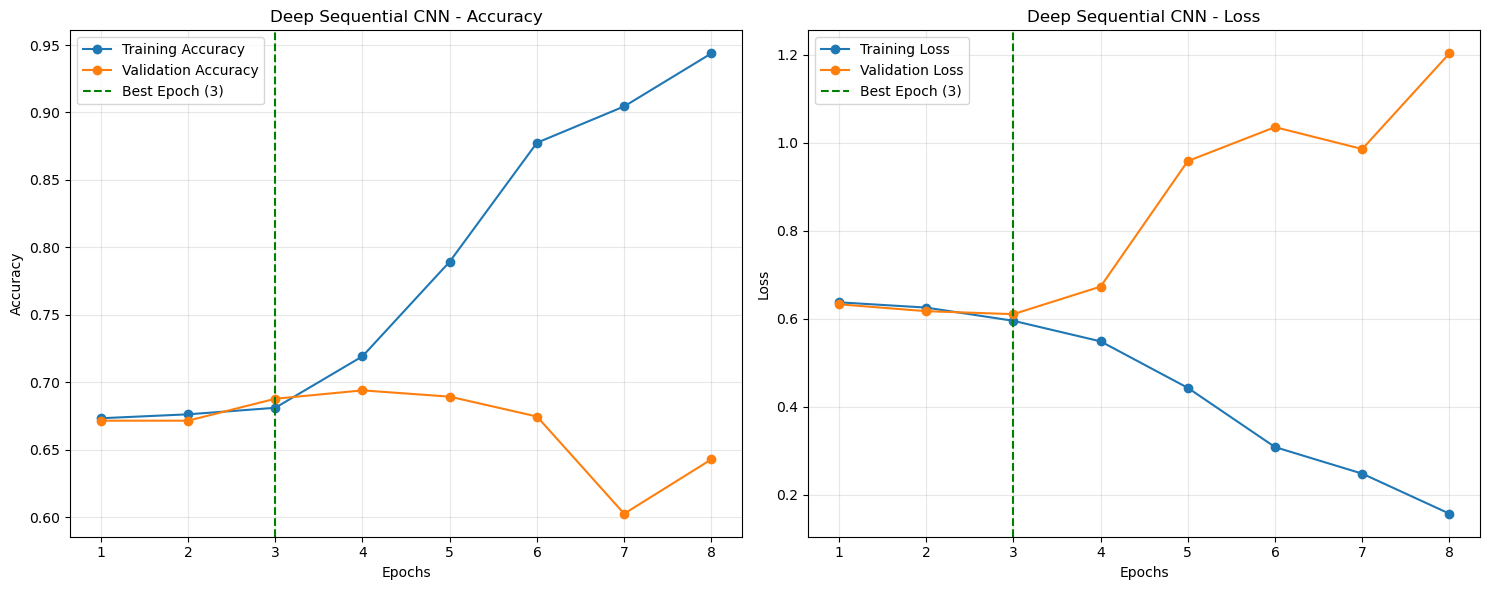

In [46]:

# Extract Early Stopping Details
best_epoch_idx_deep = early_stopping_deep.best_epoch
best_epoch_num_deep = best_epoch_idx_deep + 1
stopped_epoch_idx_deep = early_stopping_deep.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY ---")
if stopped_epoch_idx_deep > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_deep + 1}.")
else:
    print(f"Training completed all epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_deep}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_deep}!")

# Extract the exact metrics recorded during that best epoch
best_train_loss_deep = history_deep.history['loss'][best_epoch_idx_deep]
best_train_acc_deep = history_deep.history['accuracy'][best_epoch_idx_deep]
best_val_loss_deep = history_deep.history['val_loss'][best_epoch_idx_deep]
best_val_acc_deep = history_deep.history['val_accuracy'][best_epoch_idx_deep]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_deep:.4f} | Training Accuracy:   {best_train_acc_deep:.4f}")
print(f"Validation Loss: {best_val_loss_deep:.4f} | Validation Accuracy: {best_val_acc_deep:.4f}")
print("="*40 + "\n")

# Evaluate the Model (This proves the weights were restored!)
print("--- Final Deep Sequential CNN Evaluation (Using Restored Weights) ---")
# Print the exact history numbers instead of re-evaluating the training set
print(f"Final Training Loss: {best_train_loss_deep:.4f}")
print(f"Final Training Accuracy: {best_train_acc_deep:.4f}")

# Evaluate the validation set to prove the weights restored correctly
val_loss_deep, val_acc_deep = deep_cnn_model.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Loss: {val_loss_deep:.4f}")
print(f"Final Evaluated Validation Accuracy: {val_acc_deep:.4f}\n")

# Plot the results
plot_learning_curves(history_deep, "Deep Sequential CNN", best_epoch_num_deep)

#### 7.3 Parallel Multi-Kernel CNN

##### 7.3.1 Architecture

In [47]:
# Define the Input layer
inputs_multi = Input(shape=(max_length,))

# Add the Embedding Layer
embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(inputs_multi)

# Branch 1: Trigrams (Scans 3 words at a time)
branch_1 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding)
branch_1 = GlobalMaxPooling1D()(branch_1)

# Branch 2: 4-grams (Scans 4 words at a time)
branch_2 = Conv1D(filters=128, kernel_size=4, activation='relu')(embedding)
branch_2 = GlobalMaxPooling1D()(branch_2)

# Branch 3: 5-grams (Scans 5 words at a time)
branch_3 = Conv1D(filters=128, kernel_size=5, activation='relu')(embedding)
branch_3 = GlobalMaxPooling1D()(branch_3)

# Concatenate branches and pass to output
merged = concatenate([branch_1, branch_2, branch_3])
dropout = Dropout(0.5)(merged)
outputs_multi = Dense(1, activation='sigmoid')(dropout)

# Build and Compile the Model
model_3 = Model(inputs=inputs_multi, outputs=outputs_multi)

model_3.compile(
    optimizer='adam', 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Display the architecture
print("--- Parallel Multi-Kernel CNN Model Architecture ---")
model_3.summary()

--- Parallel Multi-Kernel CNN Model Architecture ---


Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 3000, 200) │  2,000,000 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2998, 128) │     76,928 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2997, 128) │    102,528 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2996, 128) │    128,128 │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_3[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_4[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_5[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 384)       │          0 │ concatenate[0][0] │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │        385 │ dropout_12[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,307,969 (8.80 MB)

 Trainable params: 2,307,969 (8.80 MB)

 Non-trainable params: 0 (0.00 B)

##### 7.3.2 Training

In [48]:
# Reset Early Stopping for the Multi-Kernel CNN
early_stopping_multi = EarlyStopping(
    monitor='val_loss',         
    patience=5,                 
    restore_best_weights=True   
)

# Train the Parallel Multi-Kernel CNN
print("Starting Parallel Multi-Kernel CNN training...")
history_3 = model_3.fit(
    train_padded, 
    y_train, 
    epochs=10, 
    batch_size=32,
    validation_data=(val_padded, y_val),
    callbacks=[early_stopping_multi],
    verbose=1
)


Starting Parallel Multi-Kernel CNN training...
Epoch 1/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 87s 526ms/step - accuracy: 0.6687 - loss: 0.6412 - val_accuracy: 0.6716 - val_loss: 0.6317
Epoch 2/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 85s 525ms/step - accuracy: 0.6800 - loss: 0.6055 - val_accuracy: 0.6840 - val_loss: 0.6032
Epoch 3/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 84s 521ms/step - accuracy: 0.7088 - loss: 0.5749 - val_accuracy: 0.6940 - val_loss: 0.5990
Epoch 4/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 84s 521ms/step - accuracy: 0.7315 - loss: 0.5447 - val_accuracy: 0.6933 - val_loss: 0.6133
Epoch 5/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 85s 523ms/step - accuracy: 0.7532 - loss: 0.5107 - val_accuracy: 0.6995 - val_loss: 0.6325
Epoch 6/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 84s 521ms/step - accuracy: 0.7797 - loss: 0.4675 - val_accuracy: 0.6971 - val_loss: 0.6481
Epoch 7/10
162/162 ━━━━━━━━━━━━━━━━━━━━ 91s 560ms/step - accuracy: 0.7997 - loss: 0.4320 - val_accuracy: 0.6894 - val_loss: 0.6759
Epoch 8/10
162/162 ━━━━━━━━━━━━━━━━━

##### 7.3.3 Evaluation


--- EARLY STOPPING SUMMARY ---
Training was halted early at Epoch 8.
The best validation loss occurred at Epoch 3.
Model weights have been successfully restored to Epoch 3!

--- METRICS AT BEST EPOCH ---
Training Loss:   0.5749 | Training Accuracy:   0.7088
Validation Loss: 0.5990 | Validation Accuracy: 0.6940

--- Final Parallel Multi-Kernel CNN Evaluation (Using Restored Weights) ---
Final Training Loss: 0.5749
Final Training Accuracy: 0.7088
Final Evaluated Validation Loss: 0.5990
Final Evaluated Validation Accuracy: 0.6940



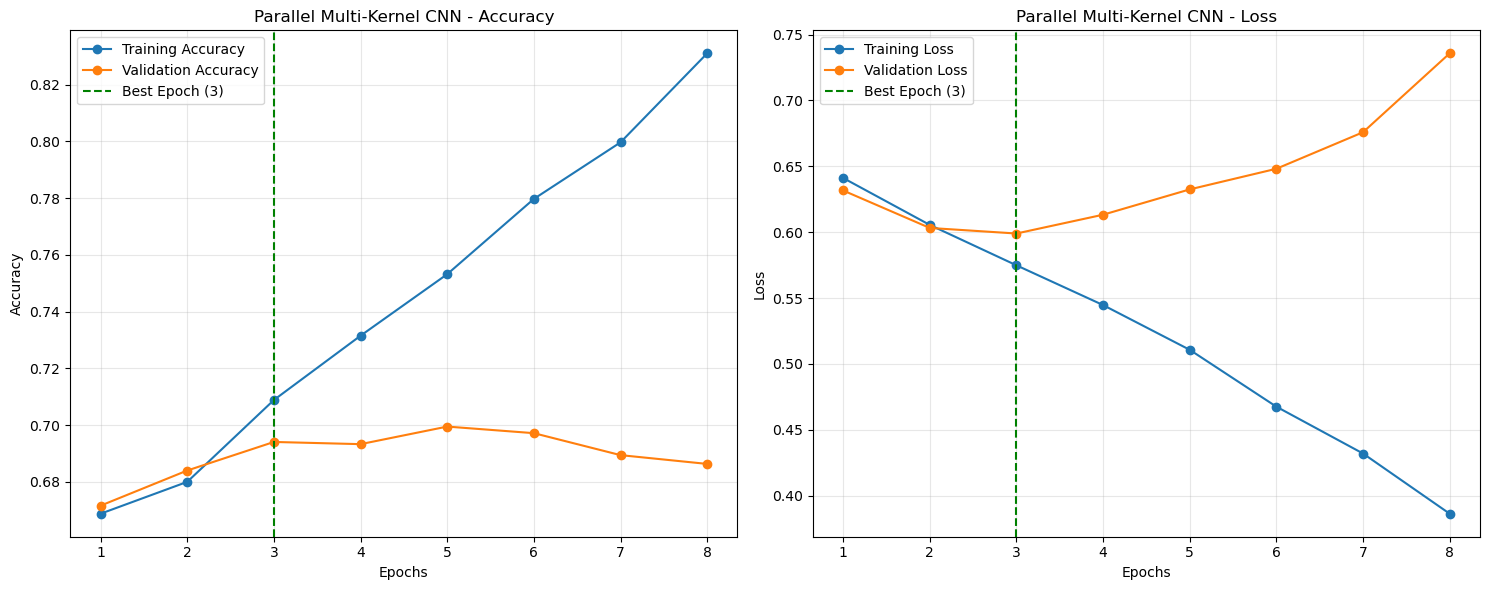

In [49]:
# Extract Early Stopping Details
best_epoch_idx_multi = early_stopping_multi.best_epoch
best_epoch_num_multi = best_epoch_idx_multi + 1
stopped_epoch_idx_multi = early_stopping_multi.stopped_epoch

print("\n" + "="*40)
print("--- EARLY STOPPING SUMMARY ---")
if stopped_epoch_idx_multi > 0:
    print(f"Training was halted early at Epoch {stopped_epoch_idx_multi + 1}.")
else:
    print(f"Training completed all epochs without triggering an early stop.")

print(f"The best validation loss occurred at Epoch {best_epoch_num_multi}.")
print(f"Model weights have been successfully restored to Epoch {best_epoch_num_multi}!")

# Extract the exact metrics recorded during that best epoch
best_train_loss_multi = history_3.history['loss'][best_epoch_idx_multi]
best_train_acc_multi = history_3.history['accuracy'][best_epoch_idx_multi]
best_val_loss_multi = history_3.history['val_loss'][best_epoch_idx_multi]
best_val_acc_multi = history_3.history['val_accuracy'][best_epoch_idx_multi]

print("\n--- METRICS AT BEST EPOCH ---")
print(f"Training Loss:   {best_train_loss_multi:.4f} | Training Accuracy:   {best_train_acc_multi:.4f}")
print(f"Validation Loss: {best_val_loss_multi:.4f} | Validation Accuracy: {best_val_acc_multi:.4f}")
print("="*40 + "\n")

# Evaluate the Model (This proves the weights were restored!)
print("--- Final Parallel Multi-Kernel CNN Evaluation (Using Restored Weights) ---")
# Print the exact history numbers instead of re-evaluating the training set
print(f"Final Training Loss: {best_train_loss_multi:.4f}")
print(f"Final Training Accuracy: {best_train_acc_multi:.4f}")

# Evaluate the validation set to prove the weights restored correctly
val_loss_multi, val_acc_multi = model_3.evaluate(val_padded, y_val, verbose=0)
print(f"Final Evaluated Validation Loss: {val_loss_multi:.4f}")
print(f"Final Evaluated Validation Accuracy: {val_acc_multi:.4f}\n")

# Plot the results
plot_learning_curves(history_3, "Parallel Multi-Kernel CNN", best_epoch_num_multi)